# Breast Cancer Data Preprocessor

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../data/rawData/data.csv")

## Preprocessing
Steps used for preprocessing:
- Mapping
- Splitting
- Feature Scaling (Standardization)

In [3]:
# Remove the id column and the trailing empty column
df = df.drop(["id", "Unnamed: 32"], axis=1, errors="ignore")

### Mapping

We convert the diagnosis to numerical values rather than strings.

In [4]:
df["diagnosis"] = df["diagnosis"].map({'M': 1, 'B': 0})

df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


### Separate Features and Labels


In [5]:
# Features and Labels
X = df.drop("diagnosis", axis=1)
Y = df["diagnosis"]

### Feature Scaling 

We use the standardization formula to scaled our dataset:
$$z = \frac{x -\mu}{\sigma}$$

Where:
- $x$ is the feature
- $\mu$ is the mean of the feature
- $\sigma$ is the stadard deviation of the feature

In [6]:
X_mean = X.mean()
X_std = X.std()

In [7]:
X_scaled = (X - X_mean) / X_std

X_scaled

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.096100,-2.071512,1.268817,0.983510,1.567087,3.280628,2.650542,2.530249,2.215566,2.253764,...,1.885031,-1.358098,2.301575,1.999478,1.306537,2.614365,2.107672,2.294058,2.748204,1.935312
1,1.828212,-0.353322,1.684473,1.907030,-0.826235,-0.486643,-0.023825,0.547662,0.001391,-0.867889,...,1.804340,-0.368879,1.533776,1.888827,-0.375282,-0.430066,-0.146620,1.086129,-0.243675,0.280943
2,1.578499,0.455786,1.565126,1.557513,0.941382,1.052000,1.362280,2.035440,0.938859,-0.397658,...,1.510541,-0.023953,1.346291,1.455004,0.526944,1.081980,0.854222,1.953282,1.151242,0.201214
3,-0.768233,0.253509,-0.592166,-0.763792,3.280667,3.399917,1.914213,1.450431,2.864862,4.906602,...,-0.281217,0.133866,-0.249720,-0.549538,3.391291,3.889975,1.987839,2.173873,6.040726,4.930672
4,1.748758,-1.150804,1.775011,1.824624,0.280125,0.538866,1.369806,1.427237,-0.009552,-0.561956,...,1.297434,-1.465481,1.337363,1.219651,0.220362,-0.313119,0.612640,0.728618,-0.867590,-0.396751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.109139,0.720838,2.058974,2.341795,1.040926,0.218868,1.945573,2.318924,-0.312314,-0.930209,...,1.899514,0.117596,1.751022,2.013529,0.378033,-0.273077,0.663928,1.627719,-1.358963,-0.708467
565,1.703356,2.083301,1.614511,1.722326,0.102368,-0.017817,0.692434,1.262558,-0.217473,-1.057681,...,1.535369,2.045599,1.420690,1.493644,-0.690623,-0.394473,0.236365,0.733182,-0.531387,-0.973122
566,0.701667,2.043775,0.672084,0.577445,-0.839745,-0.038646,0.046547,0.105684,-0.808406,-0.894800,...,0.560868,1.373645,0.578492,0.427529,-0.808876,0.350427,0.326479,0.413705,-1.103578,-0.318129
567,1.836725,2.334403,1.980781,1.733693,1.524426,3.269267,3.294046,2.656528,2.135315,1.042778,...,1.959515,2.235958,2.301575,1.651717,1.429169,3.901415,3.194794,2.287972,1.917396,2.217684


## Data Split

A $80\%$ training and $20\%$ testing set, stratified by diagnosis to preserve the class distribution (~37% malignant, ~63% benign) in both splits.

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y, test_size=0.2, random_state=42, stratify=Y
)

In [9]:
X_train.to_csv("../data/processedData/X_train_scaled.csv")
Y_train.to_csv("../data/processedData/Y_train.csv")

X_test.to_csv("../data/processedData/X_test_scaled.csv")
Y_test.to_csv("../data/processedData/Y_test.csv")

## Feature Correlation Heatmap

A heatmap of the Pearson correlation between every pair of features in the training set. Highly correlated features (|r| > 0.9) carry redundant information — for example, `radius_mean`, `perimeter_mean`, and `area_mean` are geometrically linked and move together.

This helps explain model complexity and motivates potential future dimensionality reduction.

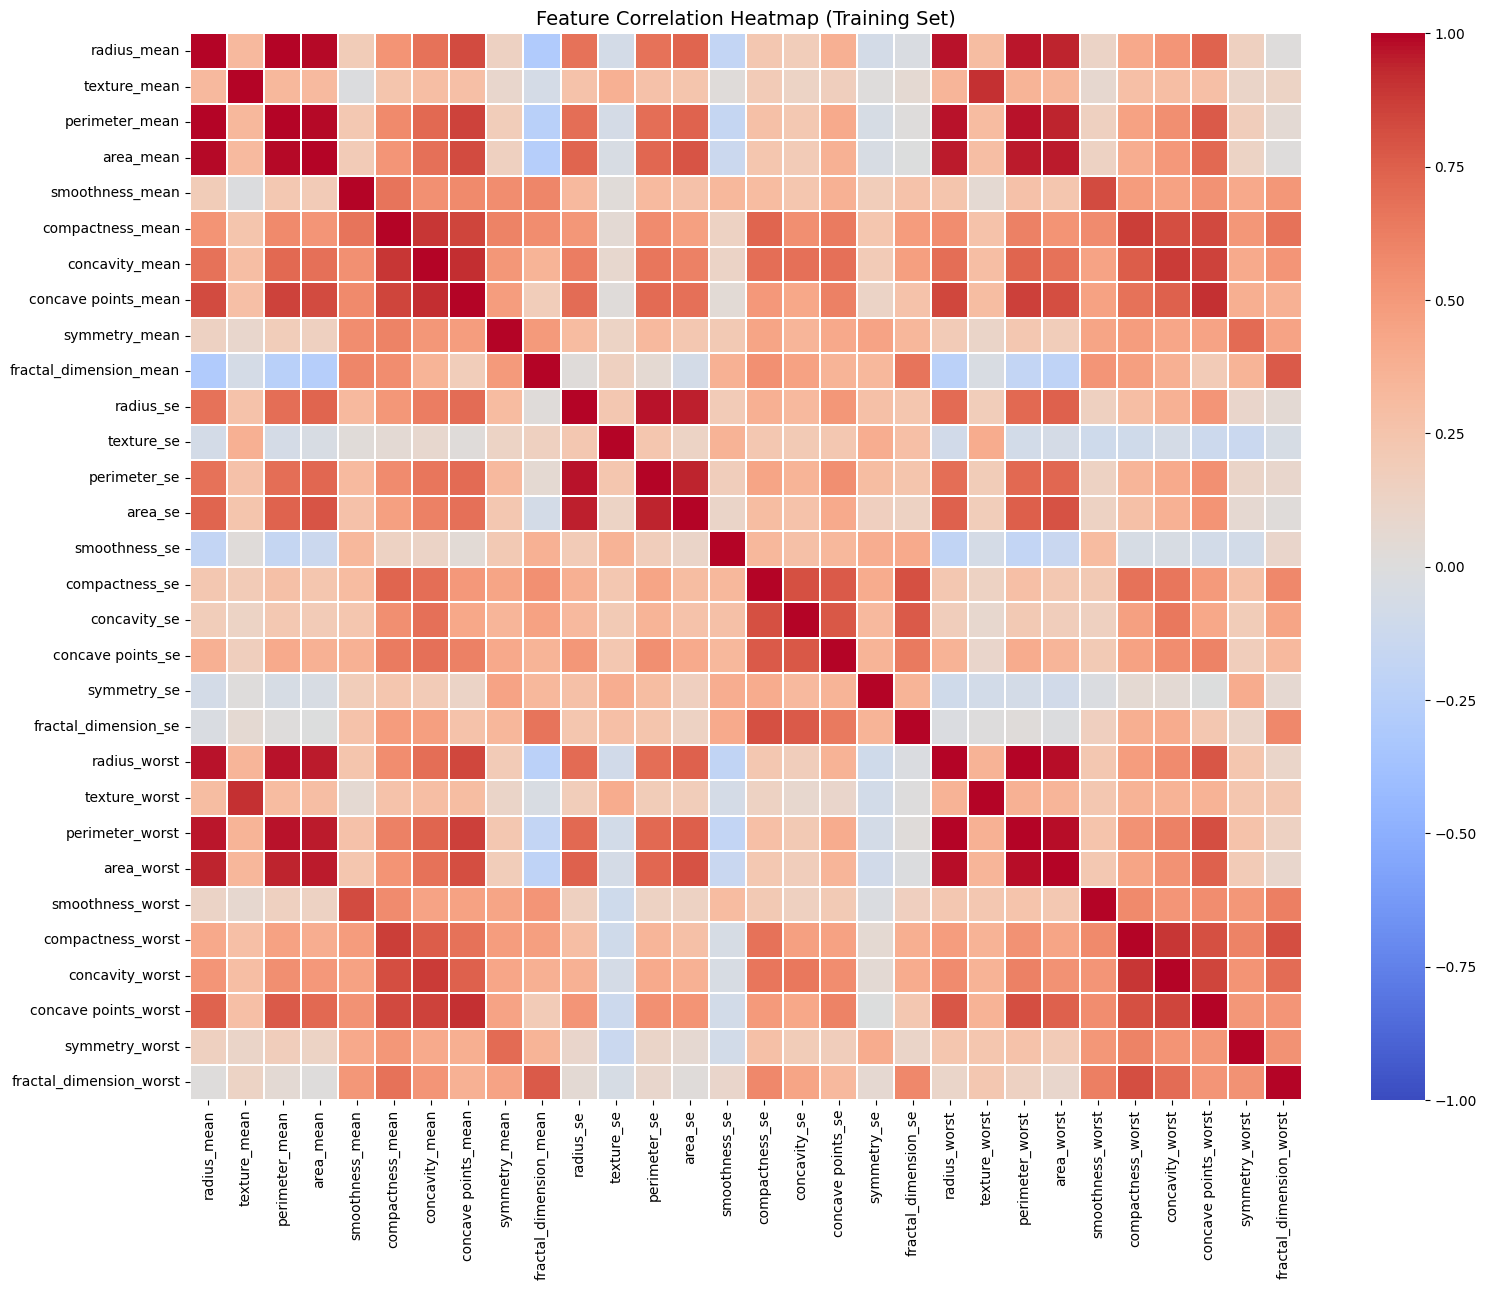

Highly correlated feature pairs (|r| > 0.95):
radius_mean      perimeter_mean     0.997815
radius_worst     perimeter_worst    0.993719
radius_mean      area_mean          0.986740
perimeter_mean   area_mean          0.985960
radius_worst     area_worst         0.983107
perimeter_worst  area_worst         0.976665
radius_se        perimeter_se       0.974705
perimeter_mean   perimeter_worst    0.970006
                 radius_worst       0.969332
radius_mean      radius_worst       0.969256
                 perimeter_worst    0.964439
area_mean        radius_worst       0.960725
                 area_worst         0.958177
                 perimeter_worst    0.956714
radius_se        area_se            0.951558
radius_mean      radius_mean             NaN


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = X_train.corr()

plt.figure(figsize=(16, 13))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    annot=False,
)
plt.title("Feature Correlation Heatmap (Training Set)", fontsize=14)
plt.tight_layout()
plt.show()

# Print feature pairs with very high correlation (|r| > 0.95)
high_corr = (
    corr.abs()
    .where(lambda df: (df > 0.95) & (df < 1.0))
    .stack()
    .drop_duplicates()
    .sort_values(ascending=False)
)
print("Highly correlated feature pairs (|r| > 0.95):")
print(high_corr.to_string())